# Прогноз удоя и вкуса молока для фермерского хозяйства
Вы работаете в IT-компании, которая выполняет на заказ проекты по машинному обучению. К вам обратился фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».
Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже. А продавцы и технологи так и норовят приукрасить своих коровок!
Поэтому он просит вас разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Вам нужно создать две прогнозные модели для отбора бурёнок в поголовье:
1. Первая будет прогнозировать возможный удой коровы (целевой признак Удой);
2. Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак Вкус молока).
С помощью модели нужно отобрать коров по двум критериям:
- средний удой за год — не менее 6000 килограммов;
- молоко должно быть вкусным.


# Описание данных
1. Файл ferma_main.csv содержит данные о стаде фермера на текущий момент. Описание данных:
    - id — уникальный идентификатор коровы.
    - Удой, кг — масса молока, которую корова даёт в год (в килограммах).
    - ЭКЕ (Энергетическая кормовая единица) — показатель питательности корма коровы.
    - Сырой протеин, г — содержание сырого протеина в корме (в граммах).
    - СПО (Сахаро-протеиновое соотношение) — отношение сахара к протеину в корме коровы.
    - Порода — порода коровы.
    - Тип пастбища — ландшафт лугов, на которых паслась корова.
    - порода папы_быка — порода папы коровы.
    - Жирность,% — содержание жиров в молоке (в процентах).
    - Белок,% — содержание белков в молоке (в процентах).
    - Вкус молока — оценка вкуса по личным критериям фермера, бинарный признак (вкусно, не вкусно).
    - Возраст — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).
    
     Признаки в датасете ferma_main.csv можно разделить на группы.
    - Характеристики коровы: id, Порода, порода папы_быка, Возраст.
    - Характеристики корма: ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г, СПО (Сахаро-протеиновое соотношение).
    - Характеристика пастбища: Тип пастбища.
    - Характеристики молока: Удой, кг, Жирность,%, Белок,%, Вкус молока.
Такое разделение поможет вам понять, как взаимосвязаны признаки в датасете.
2. Файл ferma_dad.csv хранит имя папы каждой коровы в стаде фермера. Описание данных:
    - id — уникальный идентификатор коровы.
    - Имя Папы — имя папы коровы.
3. Файл cow_buy.csv — это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой. Описание данных:
    - Порода — порода коровы.
    - Тип пастбища — ландшафт лугов, на которых паслась корова.
    - порода папы_быка — порода папы коровы.
    - Имя_папы — имя папы коровы.
    - Текущая_жирность,% — содержание жиров в молоке (в процентах).
    - Текущий_уровень_белок,% — содержание белков в молоке (в процентах).
    - Возраст — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).
    Данные в файлах ferma_main.csv и cow_buy.csv похожи, но у датасета cow_buy.csv несколько особенностей.
    - Содержание белков и жиров в молоке указано на момент продажи — когда «ЭкоФерма» давала коровам свой корм.
    - Параметры корма ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г и СПО (Сахаро-протеиновое соотношение) отсутствуют. Технологи заказчика пересмотрели подход к кормлению: для новых коров планируется увеличить значения каждого из этих параметров на 5%.
    - Кроме того, отсутствуют признаки Удой, кг и Вкус молока. Это целевые признаки, именно их предстоит предсказать!


# 0. Импорт данных. 

In [1]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


RANDOM_STATE=42



In [2]:
# загрузка данных
df_main = pd.read_csv('datasets/ferma_main.csv', sep=';', decimal=",")
df_dad = pd.read_csv('datasets/ferma_dad.csv', sep=';', decimal=",")
df_buy = pd.read_csv('datasets/cow_buy.csv', sep=';', decimal=",")
#добавляем decimal="," в read_csv, чтобы корректно считывались числа с запятой

#df_buy.head()
df_buy.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     str    
 1   Тип пастбища             20 non-null     str    
 2   порода папы_быка         20 non-null     str    
 3   Имя_папы                 20 non-null     str    
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     str    
dtypes: float64(2), str(5)
memory usage: 1.2 KB


# 1. Предобработка данных.


Предобработка данных включает в себя:
- переименование столбцов, если это необходимо;
- поиск пропущенных значений и их заполненеи/удаление;
- поиск явных и неявных дубликатов и их удаление.

## 1.1 Именование столбцов
Так как названия столбцов не соответствуют требованиям, то их необходимо изменить. 
Основные требования именования столбцов: 
- столбцы должны прямо отображать то, что в них находится;
- должны быть написаны на одном языке и в одном регистре;
- разные слова должны быть разделены подчёркиваниями;
- не содержат пробелов в начале, в конце и в середине. 

In [3]:
df_main = df_main.rename(
    columns={
        'id': "id",
        'Удой, кг' : "milk_yield_kg",
        'ЭКЕ (Энергетическая кормовая единица)': 'energy_feed_unit', 
        'Сырой протеин, г': 'raw_protein_g',
        'СПО (Сахаро-протеиновое соотношение)': 'sugar_protein_ratio', 
        'Порода': 'breed', 
        'Тип пастбища': 'grazing_type',
        'порода папы_быка': 'father_breed',
        'Жирность,%': 'fat_percentage', 
        'Белок,%': 'protein_percentage', 
        'Вкус молока': 'milk_taste', 
        'Возраст': 'age' 
        }
    )

df_dad = df_dad.rename(columns={'Имя Папы': 'father_name',})


df_buy = df_buy.rename(
    columns={
        'Порода': "breed",
        'Тип пастбища' : "grazing_type",
        'порода папы_быка': 'father_breed', 
        'Имя_папы': 'father_name',
        'Текущая_жирность,%': 'fat_percentage', 
        'Текущий_уровень_белок,%': 'protein_percentage', 
        'Возраст': 'age' 
        }
    )

for df in (df_main, df_dad, df_buy):
    for col in df.select_dtypes(exclude='number').columns:
        df[col] = df[col].astype(str).str.strip()

print(df_main.columns.tolist())

['id', 'milk_yield_kg', 'energy_feed_unit', 'raw_protein_g', 'sugar_protein_ratio', 'breed', 'grazing_type', 'father_breed', 'fat_percentage', 'protein_percentage', 'milk_taste', 'age']


## 1.2 Поиск пропущенных значений и их заполнение

In [4]:
for name, df in [('df_main', df_main), ('df_dad', df_dad), ('df_buy', df_buy)]:
    print(f'Пропуски в {name}:', int(df.isna().sum().sum()))

Пропуски в df_main: 0
Пропуски в df_dad: 0
Пропуски в df_buy: 0


В данных нет пропусков, поэтому можем их использвать для дальнейшего анализа и обучения. 

## 1.3 Дубликаты

**Явные дубликаты.** В `df_main` и `df_dad` есть уникальный `id`, поэтому полностью совпавшие строки — это ошибка выгрузки, их удаляем. В `df_buy` идентификатора нет: две коровы могут совпасть по всем признакам и быть при этом разными животными, поэтому строки в `df_buy` не удаляем.

In [5]:
print('Явные дубликаты до очистки:',
      {'df_main': int(df_main.duplicated().sum()),
       'df_dad': int(df_dad.duplicated().sum()),
       'df_buy (не удаляем)': int(df_buy.duplicated().sum())})

df_main = df_main.drop_duplicates().reset_index(drop=True)
df_dad = df_dad.drop_duplicates().reset_index(drop=True)

# после очистки id должен быть уникальным ключом
print('После очистки: df_main', df_main.shape, '| df_dad', df_dad.shape)

Явные дубликаты до очистки: {'df_main': 5, 'df_dad': 0, 'df_buy (не удаляем)': 4}
После очистки: df_main (629, 12) | df_dad (629, 2)


**Неявные дубликаты.** Смотрим уникальные значения категориальных признаков.

In [6]:
def show_unique(df, name):
    print(f'\n {name}')
    for col in df.select_dtypes(exclude='number').columns.drop('id', errors='ignore'):
        print(f'  {col}: {sorted(df[col].unique())}')

show_unique(df_main, 'df_main'); show_unique(df_dad, 'df_dad'); show_unique(df_buy, 'df_buy')


 df_main
  breed: ['Вис Бик Айдиал', 'РефлешнСоверинг']
  grazing_type: ['Равнинное', 'Равнинные', 'Холмистое']
  father_breed: ['Айдиал', 'Айдиалл', 'Соверин']
  milk_taste: ['вкусно', 'не вкусно']
  age: ['более_2_лет', 'менее_2_лет']

 df_dad
  father_name: ['Барин', 'Буйный', 'Геркулес', 'Соловчик']

 df_buy
  breed: ['Вис Бик Айдиал', 'РефлешнСоверинг']
  grazing_type: ['равнинное', 'холмистое']
  father_breed: ['Айдиал', 'Соверин']
  father_name: ['Барин', 'Буйный', 'Геркулес', 'Соловчик']
  age: ['более_2_лет', 'менее_2_лет']


In [7]:
FIX = {'father_breed': {'Айдиалл': 'Айдиал'}, 'grazing_type': {'Равнинные': 'Равнинное', 'равнинное': 'Равнинное', 'холмистое': 'Холмистое'},}

for df in (df_main, df_buy):
    for col, mapping in FIX.items():
        df[col] = df[col].replace(mapping)

show_unique(df_main, 'df_main после очистки')


 df_main после очистки
  breed: ['Вис Бик Айдиал', 'РефлешнСоверинг']
  grazing_type: ['Равнинное', 'Холмистое']
  father_breed: ['Айдиал', 'Соверин']
  milk_taste: ['вкусно', 'не вкусно']
  age: ['более_2_лет', 'менее_2_лет']


Датафреймы очищены от явных и неявных дубликатов. 

## 1.4 Объединение `df_main` и `df_dad`
Имя отца нужно как признак для регрессии и классификации. Связь «одна корова — одно имя отца», поэтому проверяем её параметром `validate`.

In [8]:
df_main = df_main.merge(df_dad, on='id', how='left', validate='one_to_one')
df_main.head()

,id,milk_yield_kg,energy_feed_unit,raw_protein_g,sugar_protein_ratio,breed,grazing_type,father_breed,fat_percentage,protein_percentage,milk_taste,age,father_name
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,Буйный
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,Соловчик
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,Барин
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,Буйный
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,Барин


**Итоги.** Столбцы переименованы, пропусков нет. Из `df_main` удалены полные дубликаты, из `df_buy` удалений не было. Исправлены опечатки  и регистр категории. Имя отца присоединено к основному датасету.

# 2. Исследовательский анализ данных 


## 2.1 Статистический анализ


Разделим признакие на количественные и категориальные:
Количественные для `df_main`: `milk_yield_kg`, `energy_feed_unit`, `raw_protein_g`, `sugar_protein_ratio`, `fat_percentage`, `protein_percentage`.

Категориальные для `df_main`: `breed`, `grazing_type`, `father_breed`, `father_name`, `age`, `milk_taste`.

In [9]:
num_main = ['milk_yield_kg', 'energy_feed_unit', 'raw_protein_g', 'sugar_protein_ratio', 'fat_percentage', 'protein_percentage']
cat_main = ['breed', 'grazing_type', 'father_breed', 'father_name', 'age', 'milk_taste']
num_buy = ['fat_percentage', 'protein_percentage']
cat_buy = ['breed', 'grazing_type', 'father_breed', 'father_name', 'age']

def describe_data(df, num_cols, cat_cols):
    print('Количественные признаки:'); display(df[num_cols].describe().round(3))
    print('Категориальные признаки:'); display(df[cat_cols].describe())

In [10]:
print('df_main'); describe_data(df_main, num_main, cat_main)
print('df_buy');  describe_data(df_buy, num_buy, cat_buy)
print('df_dad'); display(df_dad['father_name'].value_counts())

df_main
Количественные признаки:


,milk_yield_kg,energy_feed_unit,raw_protein_g,sugar_protein_ratio,fat_percentage,protein_percentage
count,629.000,629.000,629.000,629.000,629.000,629.000
mean,6188.750,14.544,1923.364,0.913,3.604,3.076
std,1644.795,1.306,182.956,0.032,0.169,0.003
min,5204.000,10.900,1660.000,0.840,2.990,3.069
25%,5751.000,13.500,1771.000,0.890,3.590,3.074
50%,6133.000,14.700,1888.000,0.930,3.650,3.076
75%,6501.000,15.600,2062.000,0.940,3.720,3.077
max,45616.000,16.800,2349.000,0.960,3.750,3.085


Категориальные признаки:


,breed,grazing_type,father_breed,father_name,age,milk_taste
count,629,629,629,629,629,629
unique,2,2,2,4,2,2
top,Вис Бик Айдиал,Холмистое,Айдиал,Барин,более_2_лет,вкусно
freq,373,351,318,240,519,371


df_buy
Количественные признаки:


,fat_percentage,protein_percentage
count,20.000,20.000
mean,3.577,3.070
std,0.127,0.010
min,3.340,3.046
25%,3.510,3.064
50%,3.590,3.074
75%,3.650,3.076
max,3.770,3.081


Категориальные признаки:


,breed,grazing_type,father_breed,father_name,age
count,20,20,20,20,20
unique,2,2,2,4,2
top,РефлешнСоверинг,Равнинное,Соверин,Буйный,более_2_лет
freq,11,11,12,8,15


df_dad


father_name
Барин       240
Буйный      215
Соловчик    110
Геркулес     64
Name: count, dtype: int64

По наблюдениям можно сдеать след. выводы:
- в `milk_yield_kg` максимум в несколько раз превышает типичные значения — это явный выброс (ошибка ввода);
- в остальных количественных признаках грубых аномалий в сводной статистике нет; `protein_percentage` почти не варьируется;
- в категориальных признаках по 2 значения, у `father_name` — 4; признак `age` заметно несбалансирован: коров старше 2 лет заметно больше.

## 2.2 Графики

In [11]:
def hist_box(df, cols):
    for col in cols:
        fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
        sns.histplot(df[col], kde=True, ax=axes[0])
        sns.boxplot(x=df[col], ax=axes[1])
        axes[0].set_title(col); axes[0].set_ylabel('Частота'); axes[1].set_xlabel(col)
        plt.show()

def count_plots(df, cols, ncols=3):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    for ax, col in zip(np.ravel(axes), cols):
        sns.countplot(data=df, x=col, ax=ax)
        ax.set_title(col); ax.set_xlabel(''); ax.set_ylabel('Количество')
        ax.tick_params(axis='x', rotation=25)
    for ax in np.ravel(axes)[len(cols):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()


### Проверка датафрейма `df_main`

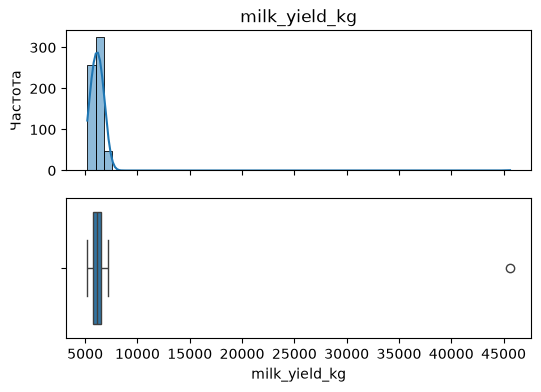

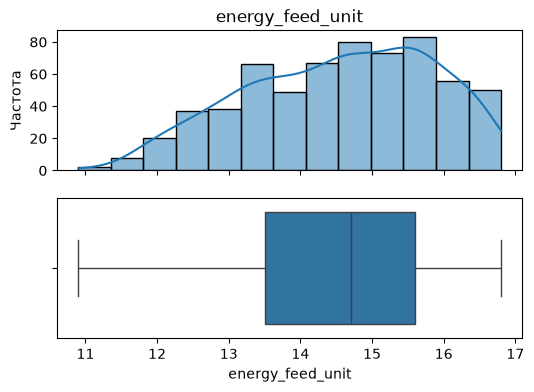

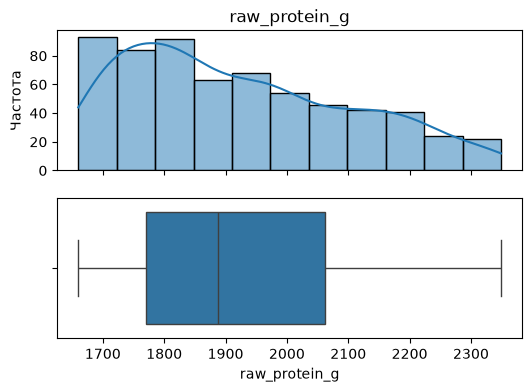

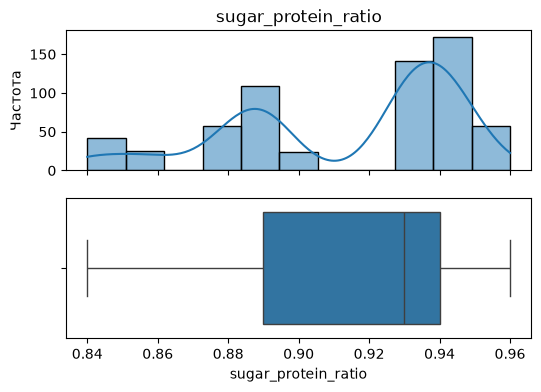

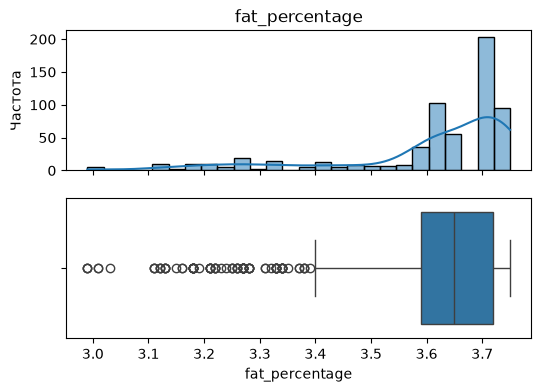

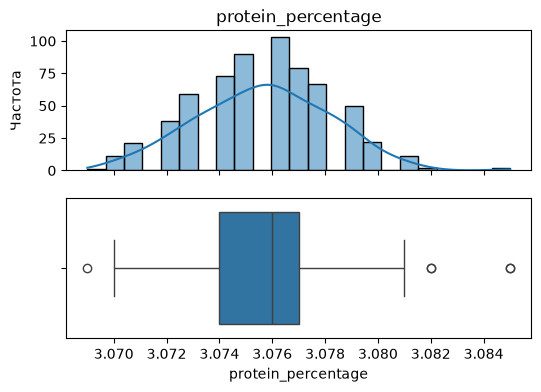

In [12]:
hist_box(df_main, num_main)

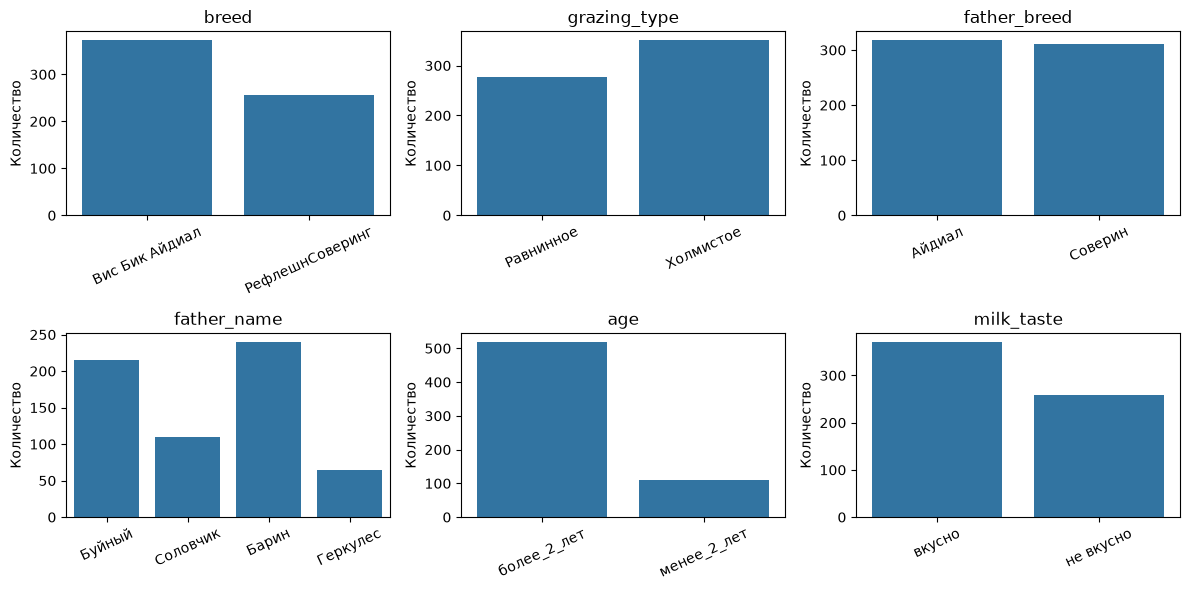

In [13]:
count_plots(df_main, cat_main)

Выбросы по графикам видны у `milk_yield_kg`, а также у `fat_percentage` и `protein_percentage`. Категориальные признаки заметно несбалансированы по `age`, по `milk_taste`, `grazing_type` и `breed` перекос умеренный.


### Выброс в `milk_yield_kg`

In [14]:
display(df_main.loc[df_main['milk_yield_kg'] > 10000, ['id', 'milk_yield_kg']])
print('Второе по величине значение:', df_main['milk_yield_kg'].nlargest(2).iloc[-1])
print('Минимум:', df_main['milk_yield_kg'].min())

,id,milk_yield_kg
16,17,45616


Второе по величине значение: 7222
Минимум: 5204


Значение выбивается в разы, и при этом оно ровно на 40 000 больше правдоподобного. Вероятная причина — лишняя цифра `4` в начале: остальные значения лежат в диапазоне примерно 5200–7200 кг. Исправляем это значение, а не удаляем строку, чтобы не терять остальные данные корове. 

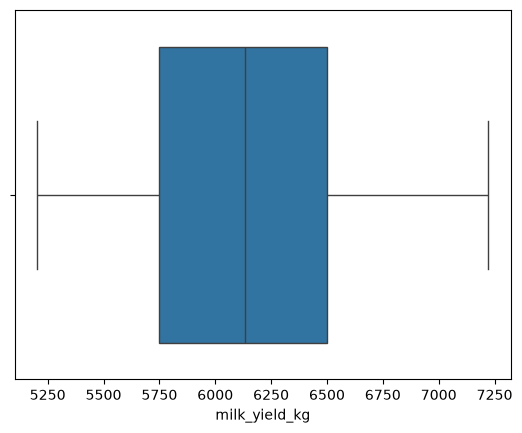

In [15]:
df_main.loc[df_main['milk_yield_kg'] > 10000, 'milk_yield_kg'] = df_main.loc[df_main['milk_yield_kg'] > 10000, 'milk_yield_kg'] - 40000

sns.boxplot(x=df_main['milk_yield_kg'])
plt.show()

### Выбросы в `fat_percentage` и `protein_percentage`

#### Проверка на выбросы столбца `milk_yield_kg`

In [16]:
def iqr_outliers(df, column):
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = df[(df[column] < lower) | (df[column] > upper)].sort_values(column)
    return out, (lower, upper)

rows = []
for col in num_main:
    out, (lo, hi) = iqr_outliers(df_main, col)
    rows.append({'признак': col, 'нижняя граница': lo, 'верхняя граница': hi,
                 'выбросов': len(out), 'доля, %': round(len(out) / len(df_main) * 100, 2)})
display(pd.DataFrame(rows).round(3))

,признак,нижняя граница,верхняя граница,выбросов,"доля, %"
0,milk_yield_kg,4613.500,7633.500,0,0.00
1,energy_feed_unit,10.350,18.750,0,0.00
2,raw_protein_g,1334.500,2498.500,0,0.00
3,sugar_protein_ratio,0.815,1.015,0,0.00
4,fat_percentage,3.395,3.915,87,13.83
5,protein_percentage,3.069,3.082,5,0.79


Доля коров младше 2 лет среди всех:  17.5 %
Доля коров младше 2 лет среди выбросов по жирности: 59.8 %


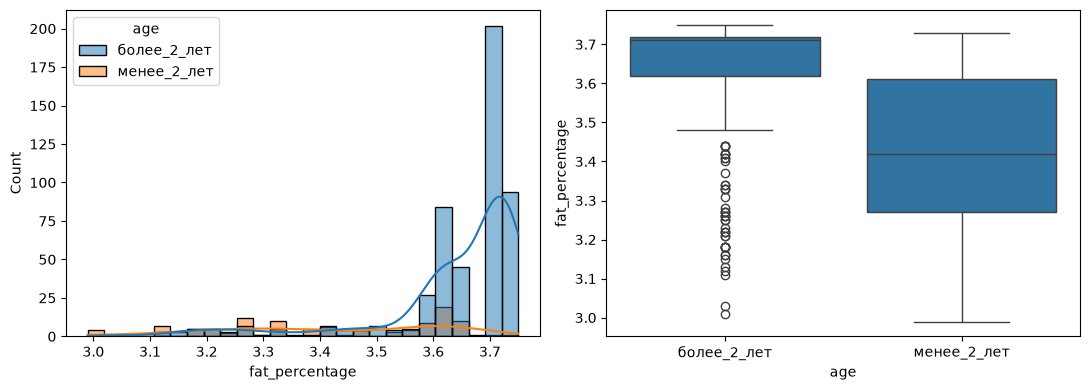

In [17]:
fat_out, _ = iqr_outliers(df_main, 'fat_percentage')
print('Доля коров младше 2 лет среди всех: ', round((df_main['age'] == 'менее_2_лет').mean() * 100, 1), '%')
print('Доля коров младше 2 лет среди выбросов по жирности:', round((fat_out['age'] == 'менее_2_лет').mean() * 100, 1), '%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=df_main, x='fat_percentage', hue='age', kde=True, ax=axes[0])
sns.boxplot(data=df_main, x='age', y='fat_percentage', ax=axes[1])
plt.tight_layout(); plt.show()

**Жирность.** Примерно 14% значений формально выходят за границы IQR — удалять их нельзя (потеряем много данных), и они объяснимы тем, что среди выбросов сильно перепредставлены коровы младше 2 лет, у которых жирность молока ниже. Это можно считать закономерностью, а не ошибкой. 

**Белок.** Основная масса значений лежит в очень узком диапазоне от 3.07 до 3.08, поэтому IQR очень мал и выбросами могут оказаться значения, которые отличаются лишь на тысячные процента. Эти данные лучше оставить. 

### Проверка на выбросы датасета `df_buy`

fat_percentage: границы [3.300; 3.860], фактический диапазон [3.34; 3.77], выбросов: 0
protein_percentage: границы [3.046; 3.094], фактический диапазон [3.046; 3.081], выбросов: 1


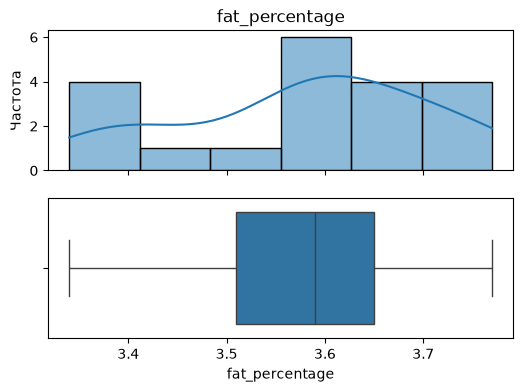

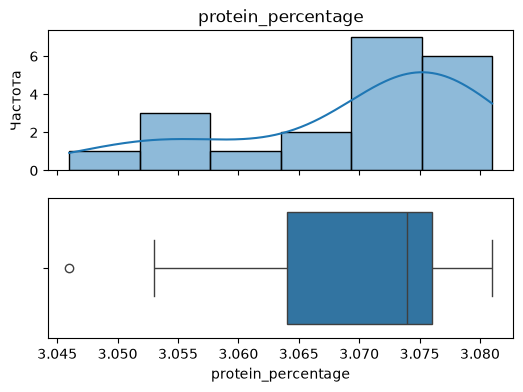

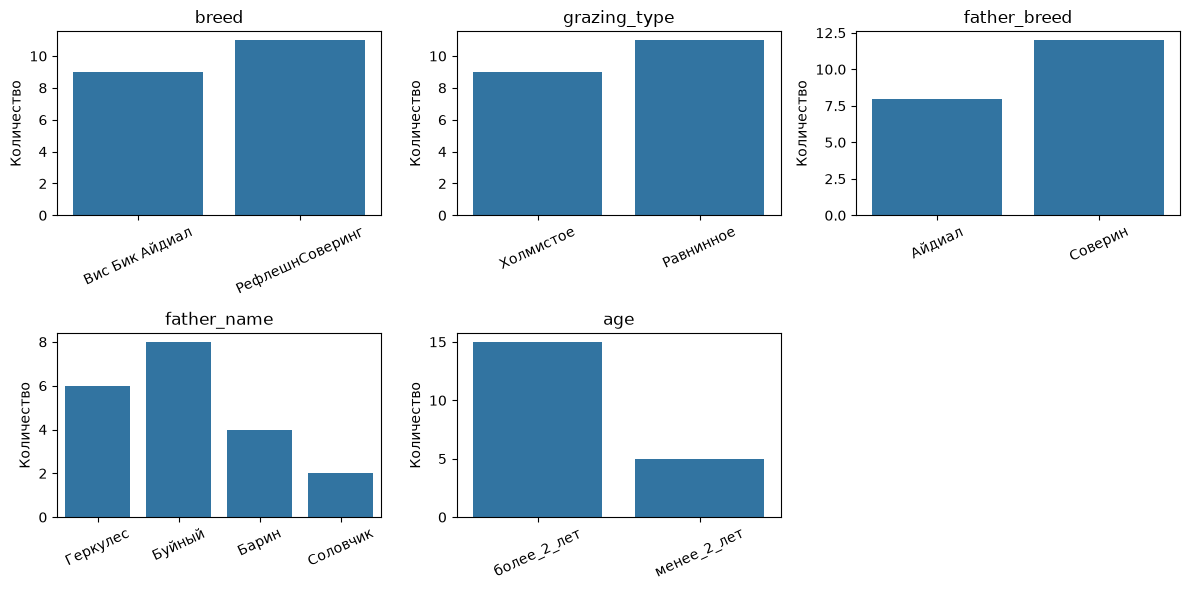

In [18]:
for col in num_buy:
    out, (lo, hi) = iqr_outliers(df_buy, col)
    print(f'{col}: границы [{lo:.3f}; {hi:.3f}], фактический диапазон [{df_buy[col].min()}; {df_buy[col].max()}], выбросов: {len(out)}')
hist_box(df_buy, num_buy)
count_plots(df_buy, cat_buy)

В `df_dad` нет измеряемых количественных признаков, поэтому искать там выбросы методом IQR бессмысленно.

 В `df_buy` значения жирности и белка находятся в пределах границ IQR, есть 1 выброс по `protein_percentage`, но опять же разница между этим выбросом и средним очень мала - лучше его оставить. Удалять коров из `df_buy` нельзя, так как для каждой необходимо сделать прогноз.

Распределения категориальных признаков в `df_buy` в целом похожи на `df_main`, кроме того что в `df_buy` всего 20 строк — оценки по ним неустойчивы.

## 2.3 Выводы

Обнаружено одно аномальное значение удоя (ошибка ввода, лишняя цифра) — исправлено. Низкая жирность у части коров объясняется их возрастом (младше 2 лет) — такие значения сохранены. Отклонения в белке ничтожны и не считаются выбросами. Дубликаты и опечатки в категориях были исправлены. Наблюдается дисбаланс по `age` (коров старше 2 лет большинство) и умеренный по `milk_taste` — это важно учитывать при разбиении выборки и при выборе метрик.
Количественные признаки имеют разные масштабы — потребуется масштабирование, для категориальных — кодирование.

# 3. Подготовка данных к МО


## 3.1 Корреляционный анализ

Изучить взаимосвязь между признаками: рассчитайте коэффициенты корреляции между всеми признаками.

Чтобы сразу увидеть коэффициенты корреляции между всеми признаками, можно воспользоваться коэфф. корреляции `phi_k`, который также определяет корреляцию между категориальными признаками и количественными. 
Для построенния корреляционной матрицы воспользуемся методом `.phik_matrix()`.
А для наглядности можно использовать `sns.heatmap()`.

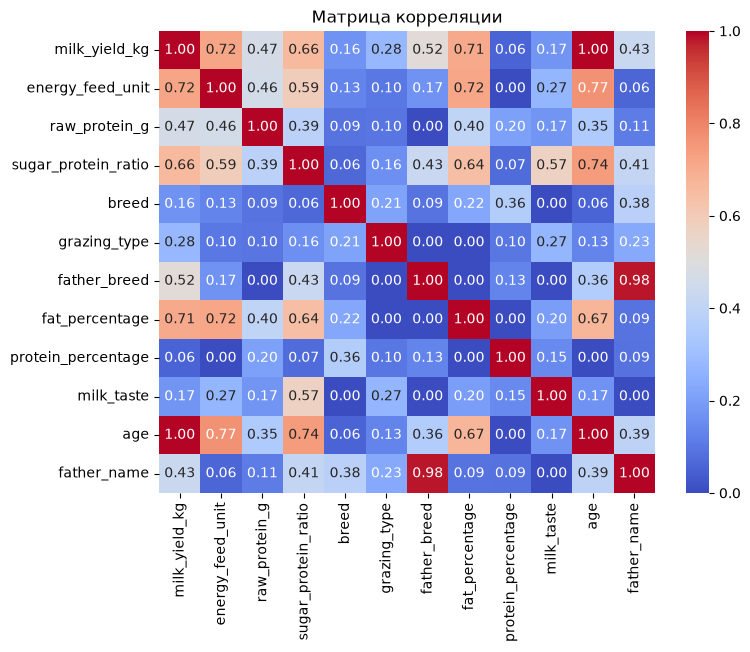

In [19]:
import phik

corr_df = df_main.drop(columns='id')

phik_matrix = corr_df.phik_matrix(interval_cols=num_main)

plt.figure(figsize=(8, 6))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Матрица корреляции")
plt.show()



По матрице `phik` сильнее всего с удоем связаны возраст, ЭКЕ, жирность и СПО, умеренно — порода отца и сырой протеин; порода, тип пастбища, белок и вкус связаны слабо. Значение `phik ≈ 1.00` между возрастом и удоем выглядит подозрительным. Необходимо дополнительно проверить связь.  

             count         mean  median   min   max
age                                                
более_2_лет    519  6269.473988  6267.0  5601  7222
менее_2_лет    110  5444.245455  5435.5  5204  6122


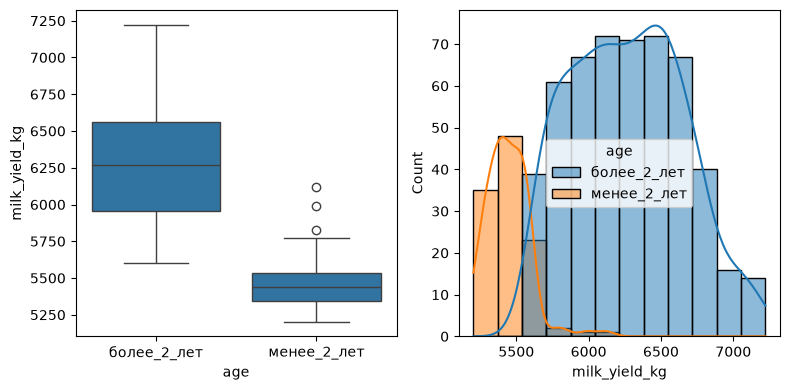

In [20]:
print(df_main.groupby('age')['milk_yield_kg'].agg(['count', 'mean', 'median', 'min', 'max']))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.boxplot(data=df_main, x='age', y='milk_yield_kg', ax=axes[0])

sns.histplot(data=df_main, x='milk_yield_kg', hue='age', kde=True, ax=axes[1])

plt.tight_layout()
plt.show()

Коровы старше 2 лет в среднем дают заметно больше молока, но диапазоны групп пересекаются: самый высокий удой молодых коров выше самого низкого удоя взрослых. Значит, связь с возрастом сильная, но не функциональная.

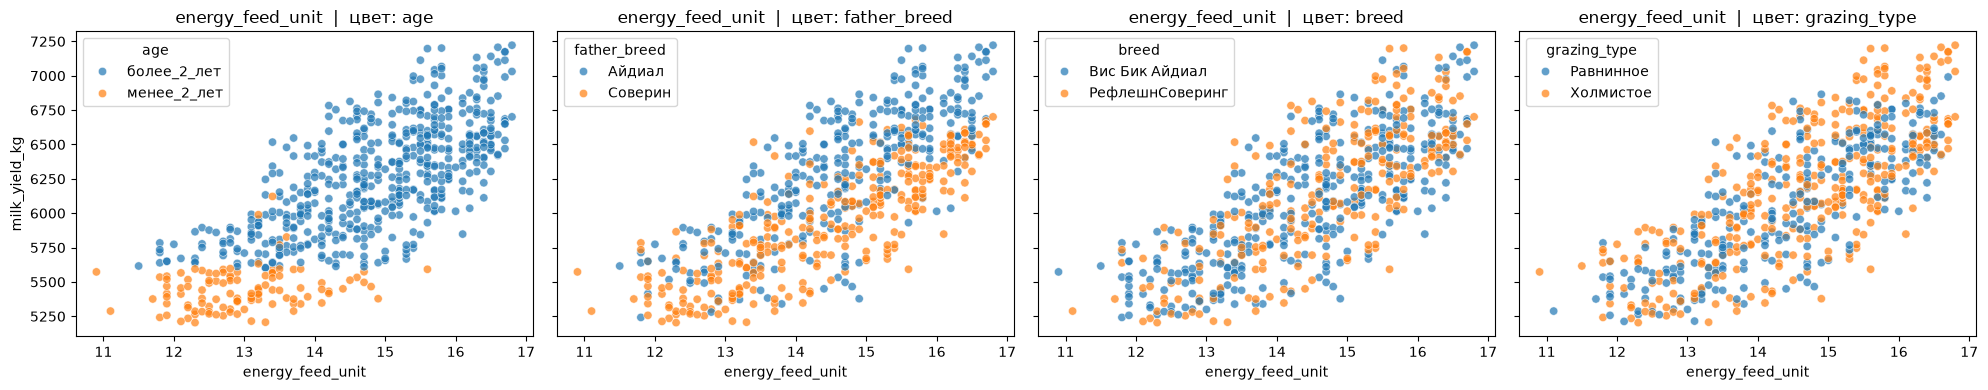

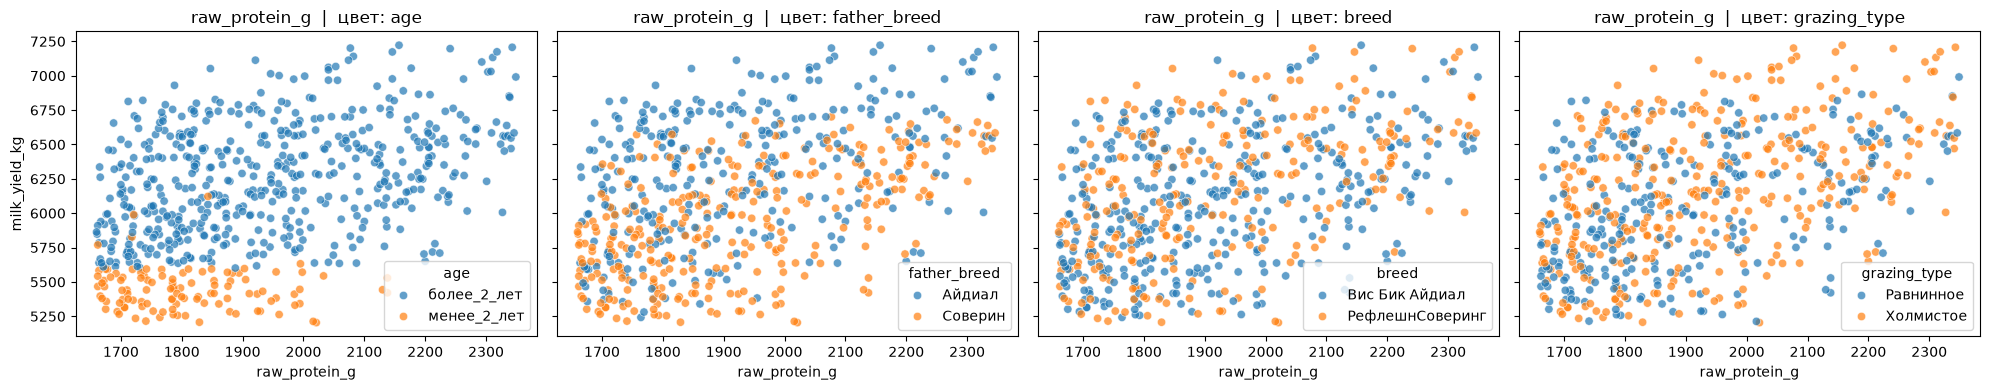

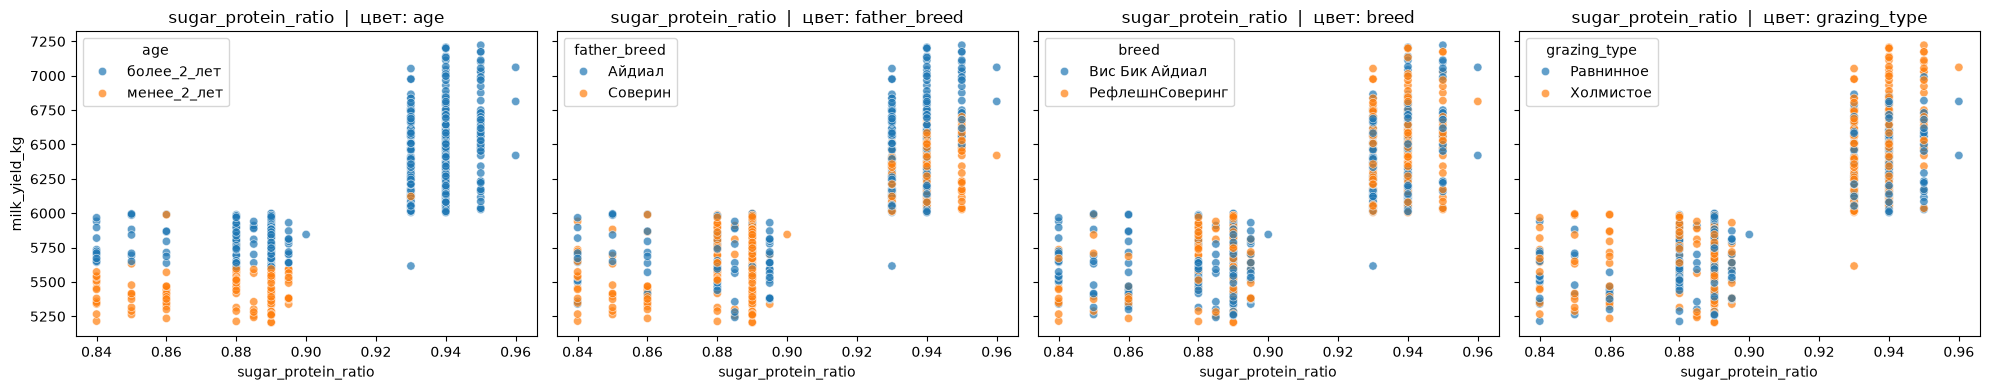

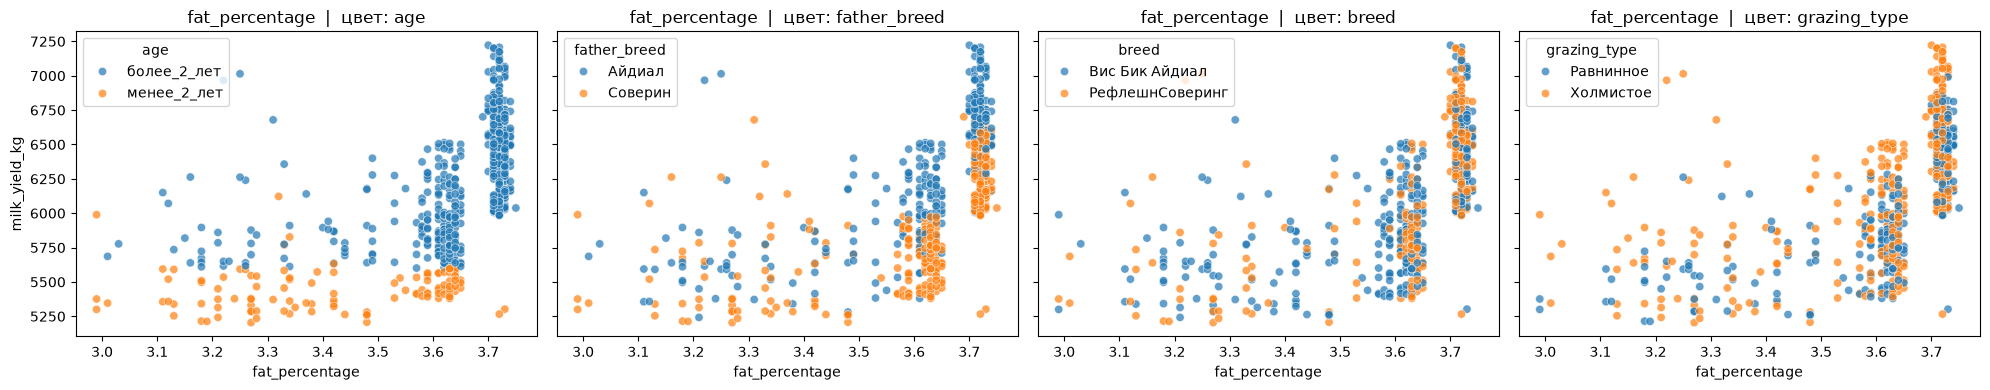

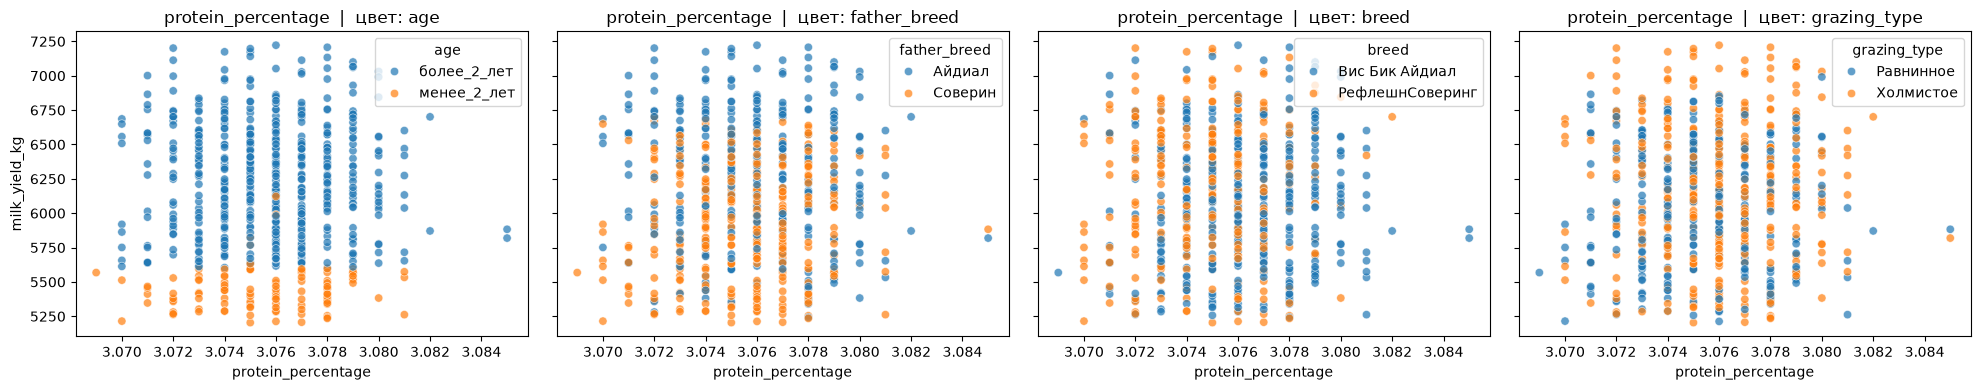

In [21]:
scatter_x = ['energy_feed_unit', 'raw_protein_g', 'sugar_protein_ratio', 'fat_percentage', 'protein_percentage']
for col in scatter_x:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
    for ax, hue in zip(axes, ['age', 'father_breed', 'breed', 'grazing_type']):
        sns.scatterplot(data=df_main, x=col, y='milk_yield_kg', hue=hue, alpha=0.7, ax=ax)
        ax.set_title(f'{col}  |  цвет: {hue}')
    plt.tight_layout()
    plt.show()



### Выбор границы для `sugar_protein_ratio`

sugar_protein_ratio,0.840,0.850,0.860,0.880,0.885,0.890,0.895,0.900,0.930,0.940,0.950,0.960
count,25.0,17.0,25.0,58.0,15.0,94.0,23.0,1.0,141.0,172.0,55.0,3.0
mean,5584.0,5607.0,5533.0,5691.0,5610.0,5696.0,5617.0,5845.0,6389.0,6459.0,6593.0,6765.0


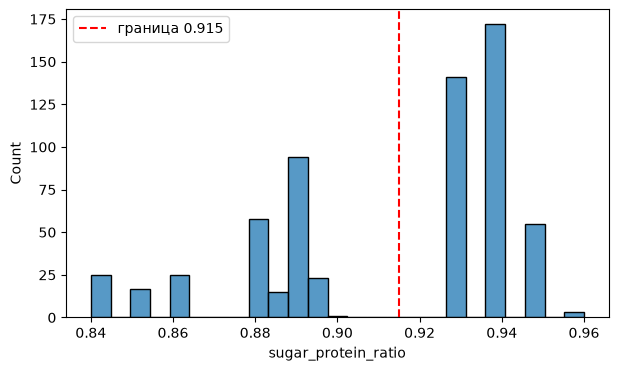

In [22]:
display(df_main.groupby('sugar_protein_ratio')['milk_yield_kg'].agg(['count', 'mean']).round(0).T)

spr_thr = 0.915 
plt.figure(figsize=(7, 4))
sns.histplot(data=df_main, x='sugar_protein_ratio', bins=25)
plt.axvline(spr_thr, color='red', ls='--', label=f'граница {spr_thr}')
plt.legend()
plt.show()

## 3.3 Выводы

- ЭКЕ - удой: связь положительная, но нелинейная — точки лежат не вдоль прямой. Для линейной модели добавляем `energy_feed_unit_sq`.
- СПО - удой: наблюдения делятся на два кластера с границей около `0.915`. Преобразуем `sugar_protein_ratio` в бинарный признак.
- Сырой протеин - удой: умеренная положительная связь с большим разбросом.
- Жирность - удой: связь есть, но точки группируются по возрасту — часть связи объясняется именно им. 
- Белок - удой: практически нет связи.
- Категориальные признаки: разбиение точек на группы заметно по `age` и `father_breed`, по `breed` и `grazing_type` — слабо.

# 4. Регрессия: прогноз удоя

## 4.0 Общая подготовка
Чтобы обучающие и новые данные (`df_buy`) обрабатывались **одинаково**, весь инжиниринг признаков вынесен в одну функцию. Разбиение на train/test делаем один раз, и все три модели сравниваются на одной и той же тестовой выборке.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error 

In [24]:
def add_features(df):
    df = df.copy()
    df['spr_bin'] = (df['sugar_protein_ratio'] > spr_thr).astype(int)
    df['energy_feed_unit_sq'] = df['energy_feed_unit'] ** 2
    return df

df_main = add_features(df_main)
y = df_main['milk_yield_kg']

train_idx, test_idx = train_test_split(df_main.index, test_size=0.2, random_state=RANDOM_STATE)
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

def build_pipeline_lin_model(num_features, cat_features, model=None):
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), list(num_features)),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), list(cat_features)),
    ])
    return Pipeline([('preprocessor', preprocessor), ('model', LinearRegression() if model is None else model)])

def split_feature_types(df, features):
    num = df[features].select_dtypes(include='number').columns.tolist()
    cat = [f for f in features if f not in num]
    return num, cat

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def regression_metrics(y_true, y_pred):
    return {'R²': r2_score(y_true, y_pred), 'MAE': mean_absolute_error(y_true, y_pred),
            'MSE': mean_squared_error(y_true, y_pred), 'RMSE': rmse(y_true, y_pred)}

def residual_analysis(y_true, y_pred, hue=None, title=''):
    resid = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(resid, kde=True, bins=20, ax=axes[0])
    axes[0].set_title('Распределение остатков')
    sns.scatterplot(x=y_pred, y=resid, hue=hue, alpha=0.8, ax=axes[1])
    axes[1].set_title('Остатки и прогноз')
    axes[1].set_xlabel('Прогноз')
    axes[1].set_ylabel('Остаток')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    print(f'{title}: средний остаток = {resid.mean():.1f} кг, std = {resid.std():.1f} кг')

reg_models, reg_preds = {}, {} 

def fit_regression(name, features):
    num, cat = split_feature_types(df_main, features)
    model = build_pipeline_lin_model(num, cat).fit(df_main.loc[train_idx, features], y_train)
    pred = pd.Series(model.predict(df_main.loc[test_idx, features]), index=test_idx)
    reg_models[name], reg_preds[name] = model, pred
    print(f'{name}: R2 = {r2_score(y_test, pred):.3f}')
    residual_analysis(y_test, pred, hue=df_main.loc[test_idx, 'age'], title=name)


## 4.1 Обучение первой модели


Признаки и обоснование выбора.
- `energy_feed_unit`, `raw_protein_g`, `sugar_protein_ratio` — характеристики корма, напрямую определяют удой;
- `breed`, `father_breed` — наследственность; `age` — сильная связь, видная выше; `grazing_type` — условия содержания;
- `fat_percentage`, `protein_percentage` — характеристики самого молока.

Исключены: `id` , `milk_taste` (оценка вкуса — субъективный результат, а не причина удоя) и целевой `milk_yield_kg`.

model 1: R2 = 0.825


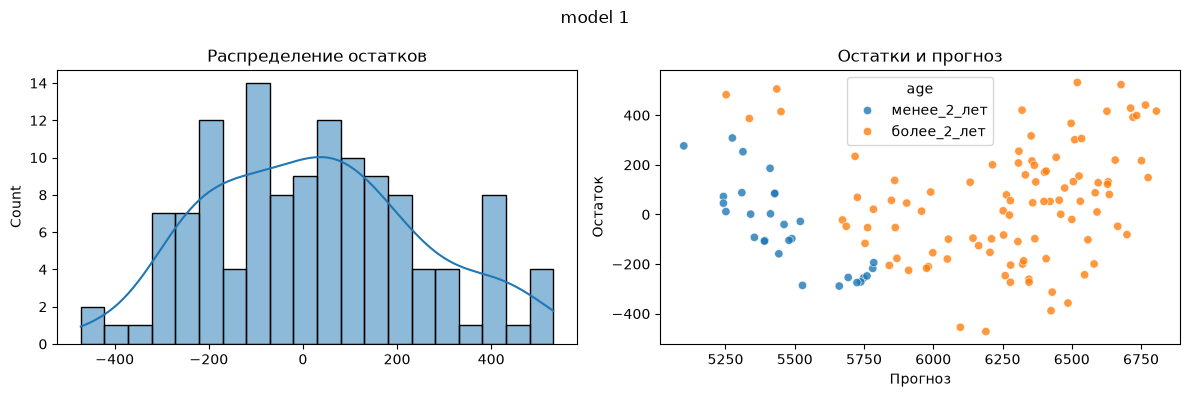

model 1: средний остаток = 24.6 кг, std = 226.1 кг


In [25]:
features_1 = ['energy_feed_unit', 'raw_protein_g', 'sugar_protein_ratio', 'breed', 'grazing_type',
              'father_breed', 'fat_percentage', 'protein_percentage', 'age']
fit_regression('model 1', features_1)

Остатки первой модели образуют неравномерную картину: на графике «остатки — прогноз» видны группы и разная ширина разброса, то есть модель не улавливает часть нелинейных связей. Это согласуется с выводами EDA: `ЭКЕ` и `СПО` связаны с удоем нелинейно.


По графикам видно, что остатки распределены неравномерно, что говорит о непостоянстве дисперсии. Заметно, что большие выбросы наблюдаются по краям графиков и образуются группы:
- предсказаниям от 5000 до 5600 соответствуют остатки в диапазоне от -300 до 500;
- предсказаниям от 5600 до 6100 соответствуют остатки от -300 до 250;
- предсказаниям от 6100 до 6800 соответствуют остатки от -450 до 500.

Это значит, что остатки распределены нелинейно. Чтобы это исправить, нужно или добавить новые признаки, или трансформировать данные, чтобы изменить взаимосвязь входных признаков с целевым. 

## 4.2 Обучение второй модели

Устраняем нелинейность: `sugar_protein_ratio` переводим в бинарный признак `spr_bin`, добавляем `energy_feed_unit_sq`.

model 2: R2 = 0.859


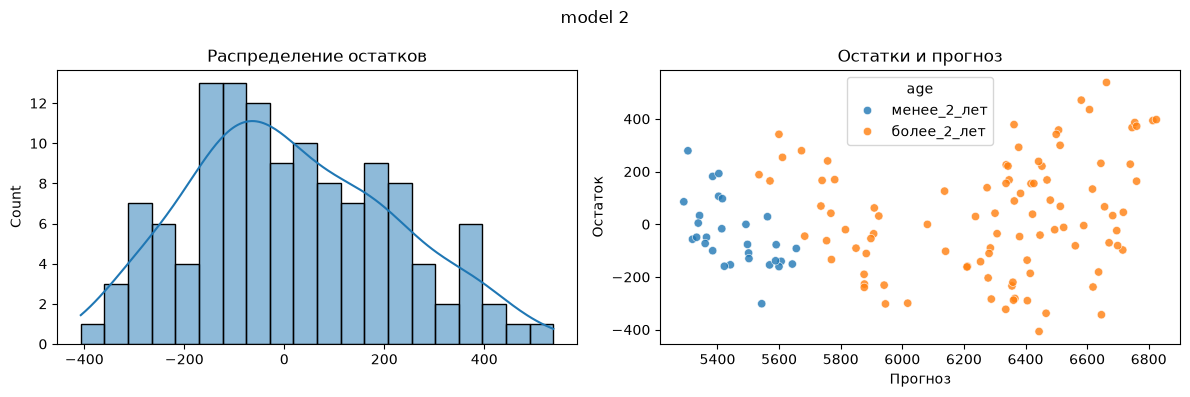

model 2: средний остаток = 15.2 кг, std = 203.3 кг


In [26]:
features_2 = ['energy_feed_unit', 'energy_feed_unit_sq', 'raw_protein_g', 'spr_bin', 'breed', 'grazing_type',
              'father_breed', 'fat_percentage', 'protein_percentage', 'age']

fit_regression('model 2', features_2)

### Выводы по второй модели

У второй модели коэффициент детерминации стал выше и составляет `r2_model2 = 0.86` по сравнению с `0.82` у предыдущей модели, трансформация данных дала положительный результат. 


Остатки также распределены неравномерно, видно их разбиение на 2 группы на графике рассеяния. Распределение по прежнему нормальное, но со смещением уже влево. 

Стоит также продолжить исследование для улучшения качества модели. 

## 4.3 Обучение третьей модели

Добавляем `father_name` (имя отца), присоединённое на этапе предобработки.



model 3: R2 = 0.873


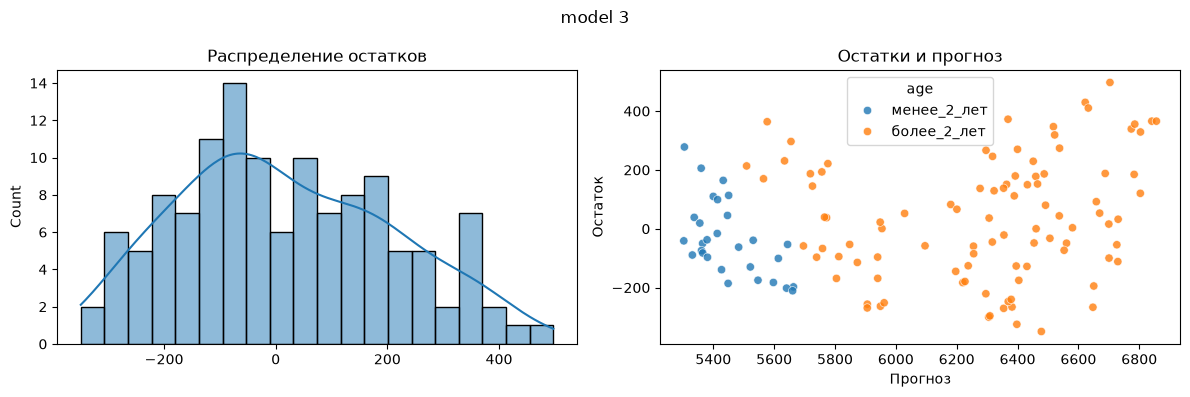

model 3: средний остаток = 18.1 кг, std = 192.6 кг


In [27]:
features_3 = features_2 + ['father_name']
fit_regression('model 3', features_3)

## 4.4 Сравнение моделей

,R²,MAE,MSE,RMSE
model 1,0.825,184.195,51328.465,226.558
model 2,0.859,165.592,41227.557,203.046
model 3,0.873,159.325,37143.578,192.727


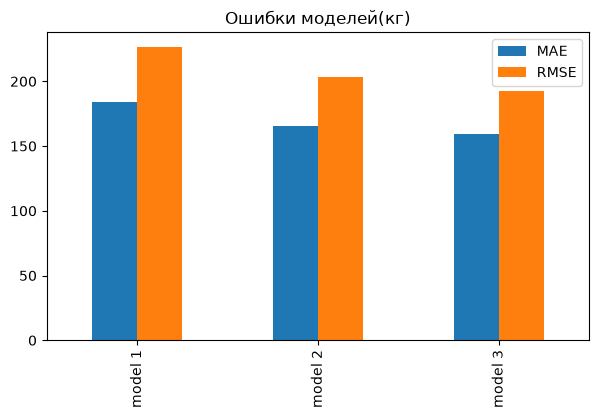

In [28]:
metrics = pd.DataFrame({name: regression_metrics(y_test, pred) for name, pred in reg_preds.items()}).T.round(3)
display(metrics)
metrics[['MAE', 'RMSE']].plot.bar(figsize=(7, 4), title='Ошибки моделей(кг)'); plt.show()

При добавлении преобразованных и новых признаков все метрики улучшались: `R²` вырос с 0.82 до 0.86 и 0.87, `RMSE` упал с 226.6 до 203.1 и 192.7 кг, `MAE` — с 184.2 до 165.6 и 159.3 кг. Лучшая модель — третья: у неё максимальный `R²` и минимальные ошибки. Выигрыш третьей модели над второй небольшой. У остатков всех моделей сохраняется структура, то есть линейная форма модели остаётся ограничением.

## 4.5 Интервал прогноза лучшей модели
Требуется оценить, в каких пределах может лежать ошибка прогноза. Считаем квантили 2.5% и 97.5% остатков на обучающих данных. Для проверки считаем долю тестовых коров, попавших в интервал.

In [29]:
final_model = reg_models['model 3']
num3, cat3 = split_feature_types(df_main, features_3)
X_train3, X_test3 = df_main.loc[train_idx, features_3], df_main.loc[test_idx, features_3]

resid_insample = y_train - final_model.predict(X_train3)
resid_test = y_test - reg_preds['model 3']

interval = pd.DataFrame({'train': resid_insample.quantile([0.025, 0.975]).values,
'test': resid_test.quantile([0.025, 0.975]).values,
}, index=['2.5%', '97.5%']).round(0)
display(interval)

lower_error, upper_error = resid_insample.quantile([0.025, 0.975])   
inside = ((resid_test >= lower_error) & (resid_test <= upper_error)).mean()
print(f'Интервал прогноза: [прогноз {lower_error:+.0f}; прогноз {upper_error:+.0f}] кг')

,train,test
2.5%,-327.0,-293.0
97.5%,363.0,372.0


Интервал прогноза: [прогноз -327; прогноз +363] кг


Интервал означает: в 95% случаев фактический удой лежит в пределах `[прогноз + нижняя_граница; прогноз + верхняя_граница]`. Если интервал заметно несимметричен, это признак небольшого смещения модели. Для осторожной оценки проверяем нижнюю границу: хватит ли даже по ней 6000 кг.

## 4.7 Прогноз удоя 
Параметры корма для новых коров: среднее значение по стаду фермера, увеличенное на 5% (по условию). Далее применяется та же функция `add_features`, что и для обучающих данных.

In [30]:
for col in ['energy_feed_unit', 'raw_protein_g', 'sugar_protein_ratio']:
    df_buy[col] = df_main[col].mean() * 1.05

df_buy = add_features(df_buy)
print('Значения spr_bin в df_buy:', df_buy['spr_bin'].unique())

df_buy['milk_yield_pred'] = final_model.predict(df_buy[features_3])
df_buy['milk_yield_low'] = df_buy['milk_yield_pred'] + lower_error
df_buy['milk_yield_high'] = df_buy['milk_yield_pred'] + upper_error
display(df_buy[['breed', 'father_name', 'age', 'milk_yield_pred', 'milk_yield_low', 'milk_yield_high']].round(0))

Значения spr_bin в df_buy: [1]


,breed,father_name,age,milk_yield_pred,milk_yield_low,milk_yield_high
0,Вис Бик Айдиал,Геркулес,более_2_лет,6523.0,6196.0,6886.0
1,Вис Бик Айдиал,Буйный,менее_2_лет,6192.0,5865.0,6554.0
2,РефлешнСоверинг,Барин,более_2_лет,6251.0,5924.0,6614.0
3,РефлешнСоверинг,Буйный,более_2_лет,6630.0,6303.0,6992.0
4,РефлешнСоверинг,Буйный,более_2_лет,6519.0,6192.0,6882.0
5,РефлешнСоверинг,Геркулес,менее_2_лет,6460.0,6133.0,6822.0
6,Вис Бик Айдиал,Геркулес,более_2_лет,6523.0,6196.0,6886.0
7,Вис Бик Айдиал,Буйный,более_2_лет,6436.0,6109.0,6799.0
8,РефлешнСоверинг,Барин,более_2_лет,6251.0,5924.0,6614.0
9,РефлешнСоверинг,Буйный,менее_2_лет,6268.0,5941.0,6630.0


C помощью финальной модели был предсказан удой, отобранных для покупки, коров. В дальнейшем, на основании предсказанных данных, можно будет сделать вывод по покупке коров. 

# 5. Классификация

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


## 5.1 Подготовка данных
Целевой признак `milk_taste` преобразуем в бинарный: `1` — «вкусно» (положительный класс), `0` — «не вкусно».

milk_taste
вкусно       371
не вкусно    258
Name: count, dtype: int64
Доля класса «вкусно»: 0.59


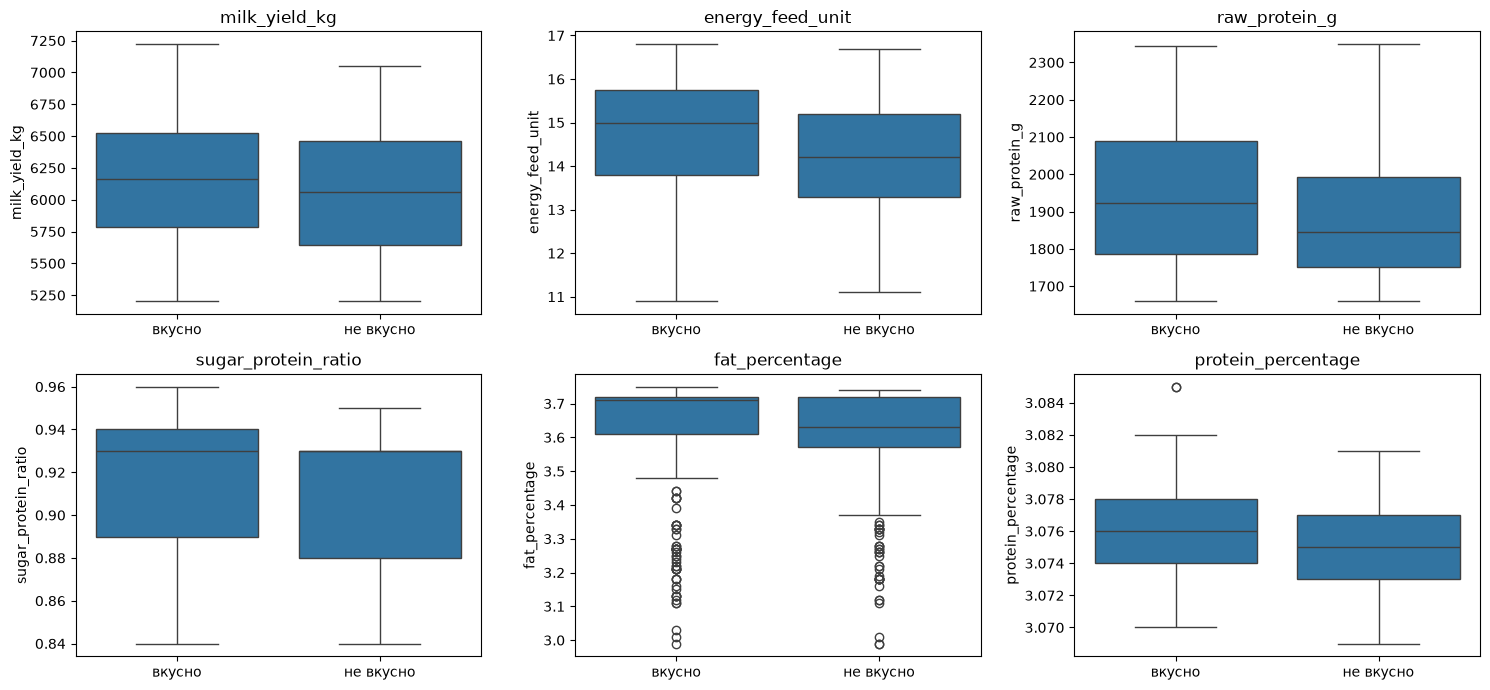

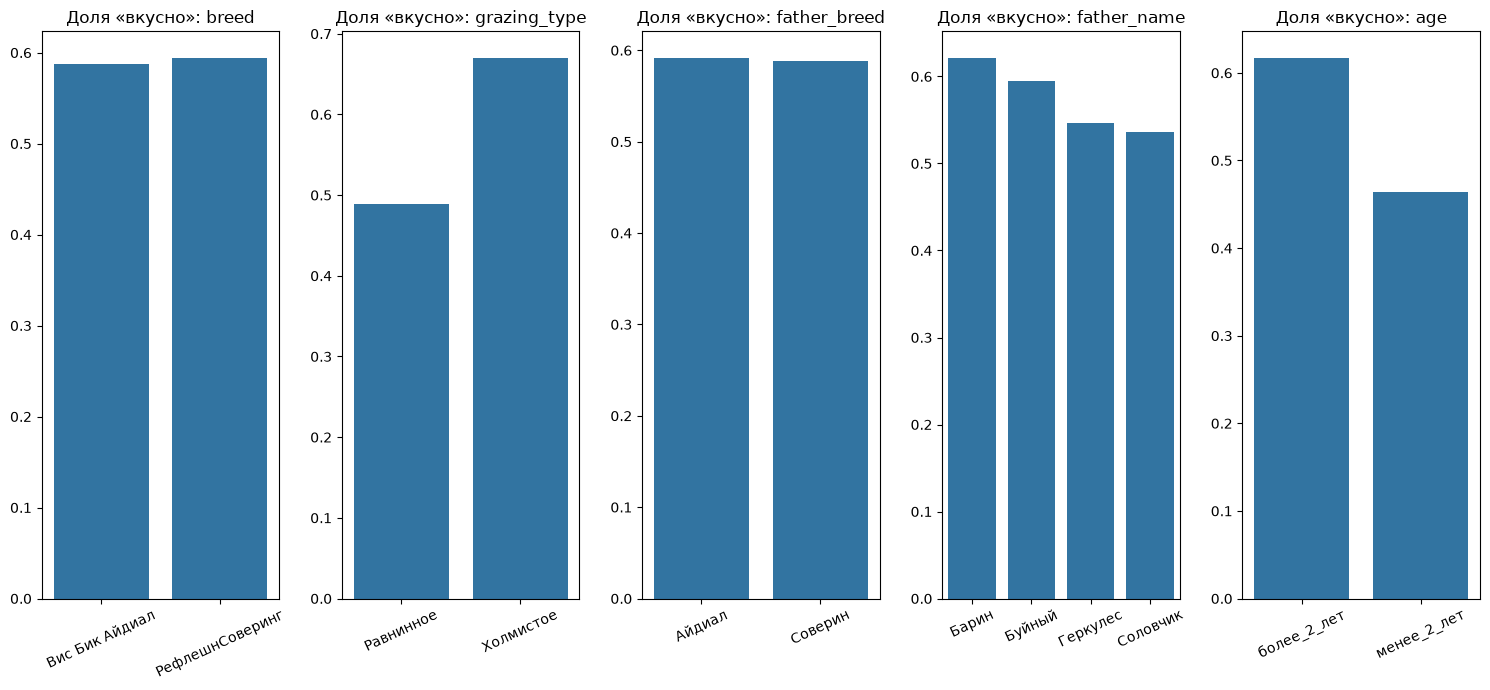

In [32]:
y_clf = (df_main['milk_taste'] == 'вкусно').astype(int)
print(y_clf.value_counts().rename({1: 'вкусно', 0: 'не вкусно'}))
print('Доля класса «вкусно»:', round(y_clf.mean(), 3))

num_view = ['milk_yield_kg', 'energy_feed_unit', 'raw_protein_g', 'sugar_protein_ratio', 'fat_percentage', 'protein_percentage']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), num_view):
    sns.boxplot(data=df_main, x='milk_taste', y=col, ax=ax); ax.set_title(col); ax.set_xlabel('')
plt.tight_layout(); plt.show()

cat_view = ['breed', 'grazing_type', 'father_breed', 'father_name', 'age']
fig, axes = plt.subplots(1, 5, figsize=(15, 7))
for ax, col in zip(axes, cat_view):
    share = pd.crosstab(df_main[col], y_clf, normalize='index')[1]
    sns.barplot(x=share.index, y=share.values, ax=ax)
    ax.set_title(f'Доля «вкусно»: {col}'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

Классы несбалансированы умеренно («вкусно» больше), поэтому выборки разбиваем **со стратификацией**, а качество оцениваем не только по `accuracy`, но и по `recall`, `precision`.

## 5.2 Обучение и оценка модели

Порог классификации по умолчанию — 0.5.

In [33]:
def build_pipeline_clf(num_features, cat_features):
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), list(num_features)),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), list(cat_features)),
    ])
    return Pipeline([('preprocessor', preprocessor),
                     ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])

Точность модели: 0.6428571428571429


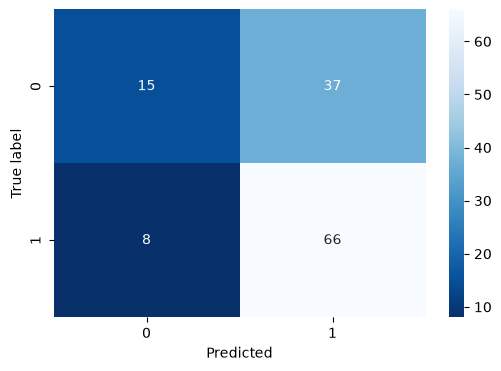

In [34]:
num_clf = ['energy_feed_unit', 'raw_protein_g', 'sugar_protein_ratio', 'fat_percentage', 'protein_percentage', 'milk_yield_kg', 'energy_feed_unit_sq', 'spr_bin']
cat_clf = ['breed', 'grazing_type', 'father_breed', 'age', 'father_name']

features_clf = num_clf + cat_clf

X_clf = df_main[features_clf]
y_clf = (df_main['milk_taste'] == 'вкусно').astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE )

clf = build_pipeline_clf(num_clf, cat_clf).fit(X_train_c, y_train_c)
proba_test = clf.predict_proba(X_test_c)[:, 1]
clf_mask = (proba_test > 0.5).astype(int)

print('Точность модели:', accuracy_score(y_test_c, clf_mask))
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test_c, clf_mask)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.xlabel('Predicted')
plt.ylabel('True label')
plt.show()


## 5.4 Анализ модели и выбор порога

Какая ошибка критичнее. Фермеру важно получить вкусное молоко.
- Ошибка I рода (FP): модель предсказала, что молоко вкусное, а молоко невкусное — фермер купит корову, которая не подходит. Это прямой убыток и главный риск.
- Ошибка II рода (FN): модель отсеяла корову с вкусным молоком — фермер лишь упускает возможность.

Следовательно, важнее precision: нужно свести FP к нулю. Соответственно из-за этого будет снижаться recall.

**Как подбираем порог.** Порог нельзя подбирать по тестовой выборке — иначе оценка на тесте станет завышенной. Поэтому вероятности для подбора считаем *out-of-fold* на обучающей выборке (5-кратная стратифицированная кросс-валидация: каждая корова оценивается моделью, которая её не видела). По этим вероятностям на сетке 0.30–0.99 ищем **наименьший порог, при котором ложноположительных нет (FP = 0)**. Тест используем только для финальной проверки.

Выбранный порог: 0.85


,accuracy,precision,recall,FP,FN,TP,TN
порог,,,,,,,
0.50,0.643,0.641,0.892,37,8,66,15
0.60,0.690,0.711,0.797,24,15,59,28
0.70,0.683,0.827,0.581,9,31,43,43
0.80,0.571,0.917,0.297,2,52,22,50
0.85,0.524,1.000,0.189,0,60,14,52
0.90,0.452,1.000,0.068,0,69,5,52


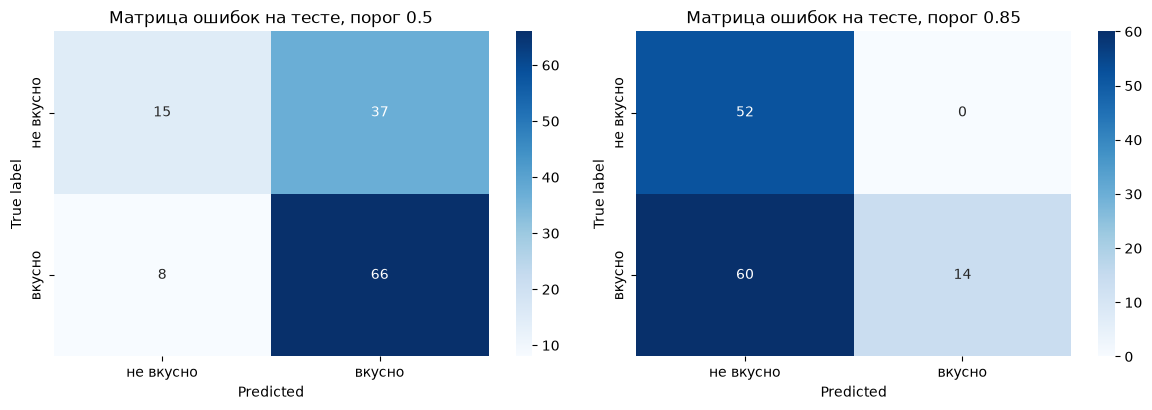

In [35]:
def clf_report(y_true, proba, thr):

    pred = (np.asarray(proba) >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {'порог': thr,
            'accuracy': accuracy_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'FP': int(fp), 'FN': int(fn), 'TP': int(tp), 'TN': int(tn)}

X_fit, X_val, y_fit, y_val = train_test_split(X_train_c, y_train_c, test_size=0.25, stratify=y_train_c, random_state=RANDOM_STATE)

clf_val = build_pipeline_clf(num_clf, cat_clf).fit(X_fit, y_fit)
proba_val = clf_val.predict_proba(X_val)[:, 1]

grid = np.round(np.arange(0.30, 1.00, 0.01), 2)
val_table = pd.DataFrame([clf_report(y_val, proba_val, t) for t in grid]).set_index('порог')
zero_fp = val_table[val_table['FP'] == 0]
THRESHOLD = float(zero_fp.index.min()) if len(zero_fp) else float(grid.max())
thr = THRESHOLD
print(f'Выбранный порог: {THRESHOLD}')
compare_thr = sorted(set([0.5, 0.6, 0.7, 0.8, 0.9, THRESHOLD]))
display(pd.DataFrame([clf_report(y_test_c, proba_test, t) for t in compare_thr]).set_index('порог').round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, t in zip(axes, [0.5, thr]):
    cm = confusion_matrix(y_test_c, (proba_test >= t).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['не вкусно', 'вкусно'], yticklabels=['не вкусно', 'вкусно'])
    ax.set_title(f'Матрица ошибок на тесте, порог {t}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True label')
plt.tight_layout()
plt.show()


In [36]:
final_rep = clf_report(y_test_c, proba_test, thr)
print(f"Тест, порог {thr}: precision = {final_rep['precision']:.3f}, recall = {final_rep['recall']:.3f}, "
      f"FP = {final_rep['FP']}, FN = {final_rep['FN']}")
if final_rep['FP'] > 0:
    print('На тесте остались ложноположительные — при ошибках этого типа порог лучше поднять ещё.')
if final_rep['recall'] < 0.2:
    print('Recall очень низкий: при таком пороге модель почти никого не одобряет. Это значит, что качество '
          'разделения классов недостаточно для надёжного отбора по строгому критерию.')

Тест, порог 0.85: precision = 1.000, recall = 0.189, FP = 0, FN = 60
Recall очень низкий: при таком пороге модель почти никого не одобряет. Это значит, что качество разделения классов недостаточно для надёжного отбора по строгому критерию.


## 5.5 Прогноз вкуса для коров «ЭкоФермы»
Подготовка данных та же, что при обучении. Если выбранный набор признаков содержит `milk_yield_kg`, подставляем прогнозный удой.

In [37]:
df_buy_clf = df_buy.assign(milk_yield_kg=df_buy['milk_yield_pred'])
missing = [c for c in features_clf if c not in df_buy_clf.columns]
assert not missing, f'нет признаков для коров на продажу: {missing}'

df_buy['taste_proba'] = clf.predict_proba(df_buy_clf[features_clf])[:, 1]
df_buy['taste_pred'] = np.where(df_buy['taste_proba'] >= THRESHOLD, 'вкусно', 'не вкусно')
display(df_buy[['breed', 'father_name', 'age', 'milk_yield_pred', 'taste_proba', 'taste_pred']].round(3))

,breed,father_name,age,milk_yield_pred,taste_proba,taste_pred
0,Вис Бик Айдиал,Геркулес,более_2_лет,6522.893,0.866,вкусно
1,Вис Бик Айдиал,Буйный,менее_2_лет,6191.600,0.877,вкусно
2,РефлешнСоверинг,Барин,более_2_лет,6250.914,0.736,не вкусно
3,РефлешнСоверинг,Буйный,более_2_лет,6629.614,0.709,не вкусно
4,РефлешнСоверинг,Буйный,более_2_лет,6519.221,0.740,не вкусно
5,РефлешнСоверинг,Геркулес,менее_2_лет,6459.782,0.282,не вкусно
6,Вис Бик Айдиал,Геркулес,более_2_лет,6522.893,0.866,вкусно
7,Вис Бик Айдиал,Буйный,более_2_лет,6436.178,0.868,вкусно
8,РефлешнСоверинг,Барин,более_2_лет,6250.914,0.736,не вкусно
9,РефлешнСоверинг,Буйный,менее_2_лет,6267.693,0.907,вкусно


# 6. Итоговый отбор

In [38]:
# критерии фермера: удой не менее 6000 кг/год и вкусное молоко
MIN_YIELD = 6000
tasty = df_buy['taste_pred'] == 'вкусно'
df_buy['ok_by_point'] = (df_buy['milk_yield_pred'] >= MIN_YIELD) & tasty        
df_buy['ok_safe'] = (df_buy['milk_yield_low'] >= MIN_YIELD) & tasty            

summary = pd.Series({
    'Коров на продажу': len(df_buy),
    'Удой ≥ 6000 по точечному прогнозу': int((df_buy['milk_yield_pred'] >= MIN_YIELD).sum()),
    'Удой ≥ 6000 даже на нижней границе интервала': int((df_buy['milk_yield_low'] >= MIN_YIELD).sum()),
    f'«Вкусно» при пороге {THRESHOLD}': int(tasty.sum()),
    'Подходят (точечный прогноз)': int(df_buy['ok_by_point'].sum()),
    'Подходят с запасом (консервативно)': int(df_buy['ok_safe'].sum()),
})
display(summary.to_frame('количество'))

cols = ['breed', 'grazing_type', 'father_breed', 'father_name', 'age',
        'milk_yield_pred', 'milk_yield_low', 'taste_proba', 'taste_pred']

print('Коровы, прошедшие только по точечному прогнозу (условные):')
display(df_buy.loc[df_buy['ok_by_point'] & ~df_buy['ok_safe'], cols].round(3))

df_buy.to_csv('cow_buy_predictions.csv', index=False, encoding='utf-8-sig')

,количество
Коров на продажу,20
Удой ≥ 6000 по точечному прогнозу,20
Удой ≥ 6000 даже на нижней границе интервала,13
«Вкусно» при пороге 0.85,7
Подходят (точечный прогноз),7
Подходят с запасом (консервативно),3


Коровы, прошедшие только по точечному прогнозу (условные):


,breed,grazing_type,father_breed,father_name,age,milk_yield_pred,milk_yield_low,taste_proba,taste_pred
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,менее_2_лет,6191.600,5864.821,0.877,вкусно
9,РефлешнСоверинг,Холмистое,Айдиал,Буйный,менее_2_лет,6267.693,5940.914,0.907,вкусно
13,Вис Бик Айдиал,Холмистое,Соверин,Барин,менее_2_лет,6013.705,5686.926,0.886,вкусно
16,Вис Бик Айдиал,Холмистое,Соверин,Соловчик,более_2_лет,6314.632,5987.853,0.851,вкусно


In [39]:
final_clf_rep = clf_report(y_test_c, proba_test, THRESHOLD)
m3 = regression_metrics(y_test, reg_preds['model 3'])
print(f'''Итог в цифрах
- Регрессия (модель 3): R² = {m3['R²']:.2f}, MAE = {m3['MAE']:.0f} кг, RMSE = {m3['RMSE']:.0f} кг; 95%-й интервал ошибки: [{lower_error:+.0f}; {upper_error:+.0f}] кг, покрытие на тесте {inside:.0%}.
- Классификация (логистическая регрессия): accuracy на тесте при пороге 0.5 = {accuracy_score(y_test_c, (proba_test > 0.5).astype(int)):.2f}; при пороге {THRESHOLD}: precision = {final_clf_rep['precision']:.2f}, recall = {final_clf_rep['recall']:.2f}, FP на тесте = {final_clf_rep['FP']}.
- Из {len(df_buy)} коров к покупке с минимальным риском подходят: {int(df_buy['ok_safe'].sum())}; ещё {int((df_buy['ok_by_point'] & ~df_buy['ok_safe']).sum())} проходят только по точечному прогнозу.''')

Итог в цифрах
- Регрессия (модель 3): R² = 0.87, MAE = 159 кг, RMSE = 193 кг; 95%-й интервал ошибки: [-327; +363] кг, покрытие на тесте 94%.
- Классификация (логистическая регрессия): accuracy на тесте при пороге 0.5 = 0.64; при пороге 0.85: precision = 1.00, recall = 0.19, FP на тесте = 0.
- Из 20 коров к покупке с минимальным риском подходят: 3; ещё 4 проходят только по точечному прогнозу.


# ВЫВОДЫ


- Что можно купить с минимальным риском. Только коров из таблицы «рекомендуемые к покупке» выше: у них удой не ниже 6000 кг даже по нижней границе 95%-го интервала ошибки, а молоко «вкусное» при строгом пороге, подобранном так, чтобы не покупать невкусное молоко. Количество — в таблице итогов.
- Условные коровы— решение зависит от готовности фермера к риску: у них есть реальный шанс не дотянуть до 6000 кг.
- Почему строгий порог. Ошибка I рода обходится дороже, чем упустить хорошую. Поэтому модель найелена именно на минимизацию убытков.


## Рекомендации 
1. Относиться к прогнозам как к вероятностной оценке: у удоя интервал ошибки в несколько сотен килограммов, а вкус — это вероятность, а не гарантия.
2. Уточнить у «ЭкоФермы» **реальные** показатели корма и рацион для каждой коровы: сейчас они заданы одинаковыми (среднее +5%), и модель не может различать коров по кормлению.
3. Учесть, что жирность и белок у коров «ЭкоФермы» измерены на их корме; у фермера корм будет другим.
4. Для сомнительных коров запросить пробную дегустацию или данные по предыдущим лактациям.
5. После покупки собирать данные по каждой корове (удой, вкус, рацион) и переобучать модели — это сделает прогнозы точнее.

##  Выводы по моделям

**Линейная регрессия.** Качество улучшено за счёт: исправления выброса; устранения неявных дубликатов; перевода `sugar_protein_ratio` в бинарный признак по границе кластеров; добавления `energy_feed_unit_sq`; добавления `father_name`; единой функции подготовки признаков и единой тестовой выборки для честного сравнения моделей. `R²` вырос с 0.82 до 0.86 и 0.87, `RMSE` упал с 227 до 203 и 193 кг.

Можно ли ещё улучшить? Да, но в ограниченных пределах: остатки сохраняют структуру (группы), значит линейная форма не описывает часть связей. Что ещё можно сделать: взаимодействия признаков (возраст × ЭКЕ, порода × пастбище); отдельные модели для молодых и взрослых коров; нелинейные ансамбли (например, случайный лес или градиентный бустинг — в проекте не проверялись); сбор новых признаков (фактический рацион, лактация, здоровье). Существенный прирост без новых данных маловероятен: значительная часть дисперсии, вероятно, определяется факторами, которых в датасете нет.

Логистическая регрессия. Модель используется как осторожный фильтр: порог подобран так, чтобы не допускать ошибок I рода, ценой recall. Возможные улучшения: `class_weight`, регуляризация (`C`), новые признаки (взаимодействия), другие классификаторы, калибровка вероятностей и отдельный отложенный набор для выбора порога. Главное ограничение — небольшой объём данных (около 600 коров), из-за которого оценки precision/recall при высоких порогах неустойчивы.

**Логистическая регрессия (вкус молока).** При стандартном пороге 0.5 точность на тесте составила около 0.64 при доле класса «вкусно» 0.59 в данных, то есть модель лишь немного лучше константного прогноза «всё вкусно». Поэтому порог выбирался не по accuracy, а из бизнес-логики: ошибка I рода (купить корову с невкусным молоком) дороже ошибки II рода. Порог подобран на валидационной части обучающей выборки как наименьший, при котором ложноположительных нет; тест использовался только для финальной проверки. Итоговые precision, recall и число FP — в таблице и в итоговой сводке выше. Чем выше порог, тем меньше коров модель одобряет: надёжность отбора достигается ценой полноты, и это ожидаемо для модели с ограниченной разделяющей способностью.

Что ещё можно сделать для классификации: проверить, нужен ли `milk_yield_kg` среди признаков (для новых коров он сам является прогнозом с ошибкой, и эта ошибка переносится в классификатор); сравнить разные наборы признаков; попробовать другие модели; собрать признаки, которые действительно связаны со вкусом (рацион, условия содержания, результаты дегустаций).
